# **Finding Outliers**

In this lab, you will work with a cleaned dataset to perform exploratory data analysis or EDA. 
You will explore the distribution of key variables and focus on identifying outliers in this lab.

## Objectives

In this lab, you will perform the following:

-  Analyze the distribution of key variables in the dataset.

-  Identify and remove outliers using statistical methods.

-  Perform relevant statistical and correlation analysis.

#### Install and import the required libraries

In [1]:
#!pip install pandas
#!pip install matplotlib
#!pip install seaborn

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

<h3>Step 1: Load and Explore the Dataset</h3>

Load the dataset into a DataFrame and examine the structure of the data.

In [2]:
file_url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv"

#Create the dataframe
df = pd.read_csv(file_url)

#Display the top 10 records
df.head()

,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


<h3>Step 2: Plot the Distribution of Industry</h3>

Explore how respondents are distributed across different industries.

- Plot a bar chart to visualize the distribution of respondents by industry.

- Highlight any notable trends.

In [3]:
# Check unique industries
print(df['Industry'].value_counts().head(10))

Industry
Software Development                          11918
Other:                                         3077
Fintech                                        1641
Internet, Telecomm or Information Services     1629
Banking/Financial Services                     1371
Healthcare                                     1277
Manufacturing                                  1265
Retail and Consumer Services                   1264
Government                                      962
Media & Advertising Services                    894
Name: count, dtype: int64


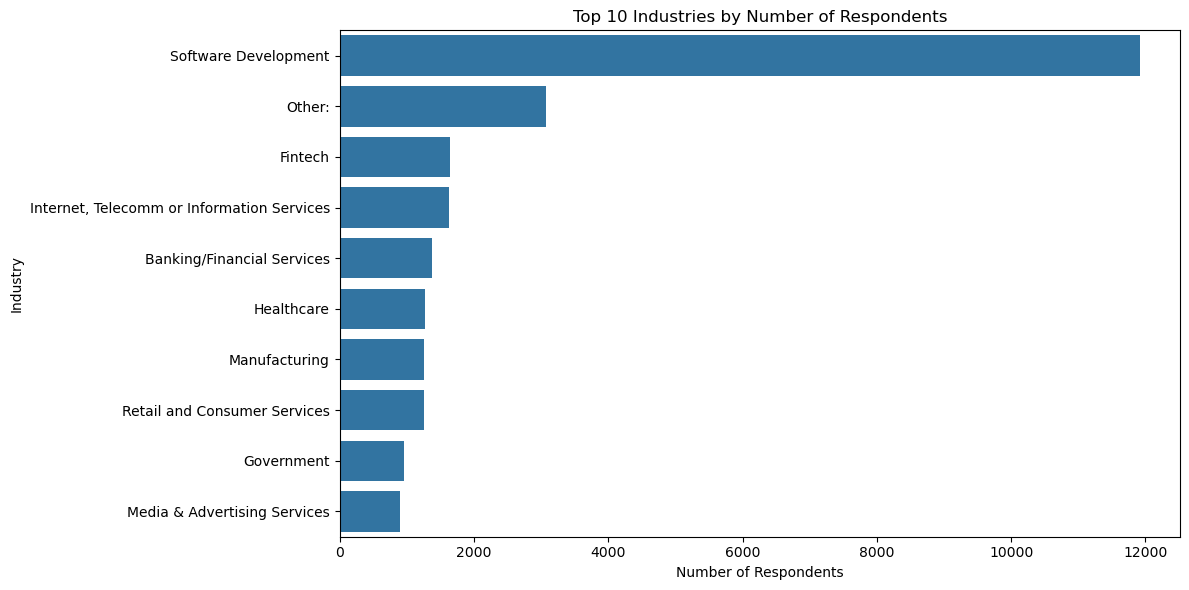

In [4]:
# Select top industries for better visualization
top_industries = df['Industry'].value_counts().nlargest(10)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_industries.values,
    y=top_industries.index
)

plt.title('Top 10 Industries by Number of Respondents')
plt.xlabel('Number of Respondents')
plt.ylabel('Industry')

plt.tight_layout()
plt.show()

<h3>Step 3: Identify High Compensation Outliers</h3>

Identify respondents with extremely high yearly compensation.

- Calculate basic statistics (mean, median, and standard deviation) for `ConvertedCompYearly`.

- Identify compensation values exceeding a defined threshold (e.g., 3 standard deviations above the mean).

In [5]:
# Convert compensation column to numeric
df['ConvertedCompYearly'] = pd.to_numeric(
    df['ConvertedCompYearly'],
    errors='coerce'
)

In [6]:
# Calculate basic statistics

mean_comp = df['ConvertedCompYearly'].mean()
median_comp = df['ConvertedCompYearly'].median()
std_comp = df['ConvertedCompYearly'].std()

print("Mean Compensation:", mean_comp)
print("Median Compensation:", median_comp)
print("Standard Deviation:", std_comp)

Mean Compensation: 86155.28726264134
Median Compensation: 65000.0
Standard Deviation: 186756.9730862951


In [7]:
# Define outlier threshold (3 standard deviations above mean)

upper_threshold = mean_comp + (3 * std_comp)

print("Outlier Threshold:", upper_threshold)

Outlier Threshold: 646426.2065215267


In [8]:
# Identify high compensation outliers

high_outliers = df[
    df['ConvertedCompYearly'] > upper_threshold
]

print("Number of High Compensation Outliers:", high_outliers.shape[0])

# Display top outlier records
print(
    high_outliers[
        ['Country', 'Employment', 'ConvertedCompYearly']
    ].head()
)

Number of High Compensation Outliers: 89
                       Country           Employment  ConvertedCompYearly
529   United States of America  Employed, full-time             650000.0
828   United States of America  Employed, full-time            1000000.0
1932  United States of America  Employed, full-time             945000.0
2171  United States of America  Employed, full-time             750000.0
2187                     Gabon  Employed, full-time            2000000.0


<h3>Step 4: Detect Outliers in Compensation</h3>

Identify outliers in the `ConvertedCompYearly` column using the IQR method.

- Calculate the Interquartile Range (IQR).

- Determine the upper and lower bounds for outliers.

- Count and visualize outliers using a box plot.

In [9]:
# Calculate Q1 and Q3

Q1 = df['ConvertedCompYearly'].quantile(0.25)
Q3 = df['ConvertedCompYearly'].quantile(0.75)

# Calculate IQR
IQR = Q3 - Q1

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)

Q1: 32712.0
Q3: 107971.5
IQR: 75259.5


In [10]:
# Determine lower and upper bounds

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

Lower Bound: -80177.25
Upper Bound: 220860.75


In [11]:
# Identify outliers

outliers = df[
    (df['ConvertedCompYearly'] < lower_bound) |
    (df['ConvertedCompYearly'] > upper_bound)
]

print("Number of Outliers:", outliers.shape[0])

Number of Outliers: 978


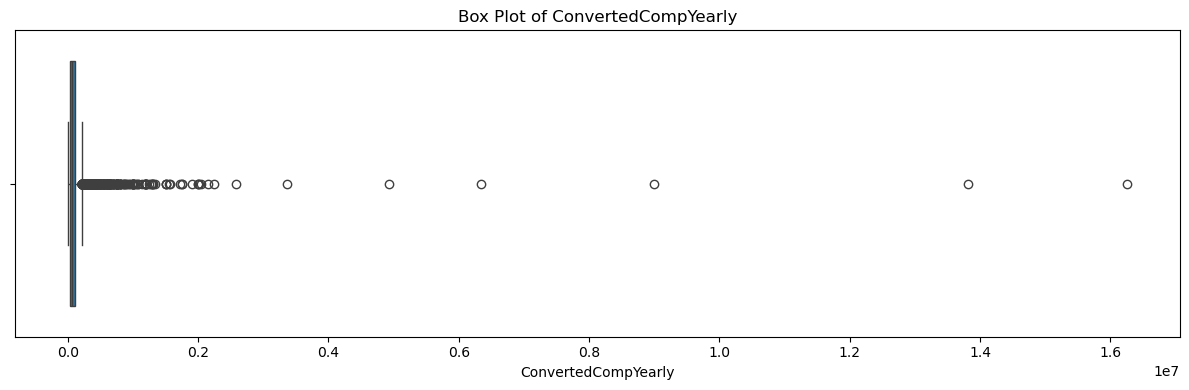

In [12]:
# Visualize outliers using box plot

plt.figure(figsize=(12,4))

sns.boxplot(
    x=df['ConvertedCompYearly']
)

plt.title('Box Plot of ConvertedCompYearly')

plt.tight_layout()
plt.show()

<h3>Step 5: Remove Outliers and Create a New DataFrame</h3>

Remove outliers from the dataset.

- Create a new DataFrame excluding rows with outliers in `ConvertedCompYearly`.
- Validate the size of the new DataFrame.

In [13]:
# Create new dataframe without outliers

df_no_outliers = df[
    (df['ConvertedCompYearly'] >= lower_bound) &
    (df['ConvertedCompYearly'] <= upper_bound)
]

In [14]:
# Compare dataset sizes

print("Original DataFrame Shape:", df.shape)
print("New DataFrame Shape:", df_no_outliers.shape)

Original DataFrame Shape: (65437, 114)
New DataFrame Shape: (22457, 114)


In [15]:
# Verify outliers removed

remaining_outliers = df_no_outliers[
    (df_no_outliers['ConvertedCompYearly'] < lower_bound) |
    (df_no_outliers['ConvertedCompYearly'] > upper_bound)
]

print("Remaining Outliers:", remaining_outliers.shape[0])

Remaining Outliers: 0


<h3>Step 6: Correlation Analysis</h3>

Analyze the correlation between `Age` (transformed) and other numerical columns.

- Map the `Age` column to approximate numeric values.

- Compute correlations between `Age` and other numeric variables.

- Visualize the correlation matrix.

In [16]:
# Map Age ranges to approximate numeric values

age_mapping = {
    "Under 18 years old": 17,
    "18-24 years old": 21,
    "25-34 years old": 29,
    "35-44 years old": 39,
    "45-54 years old": 49,
    "55-64 years old": 59,
    "65 years or older": 70
}

df['Age_numeric'] = df['Age'].map(age_mapping)

In [17]:
# Select numeric columns

numeric_df = df.select_dtypes(include=['int64', 'float64'])

In [18]:
# Compute correlation matrix

correlation_matrix = numeric_df.corr()

# Display correlations with Age_numeric
print(correlation_matrix['Age_numeric'].sort_values(ascending=False))

Age_numeric            1.000000
WorkExp                0.852538
ConvertedCompYearly    0.120809
JobSat                 0.069917
CompTotal             -0.002829
JobSatPoints_1        -0.028206
ResponseId            -0.037624
JobSatPoints_8        -0.046057
JobSatPoints_6        -0.050517
JobSatPoints_4        -0.075838
JobSatPoints_9        -0.081523
JobSatPoints_7        -0.082166
JobSatPoints_5        -0.101414
JobSatPoints_11       -0.107043
JobSatPoints_10       -0.114106
Name: Age_numeric, dtype: float64


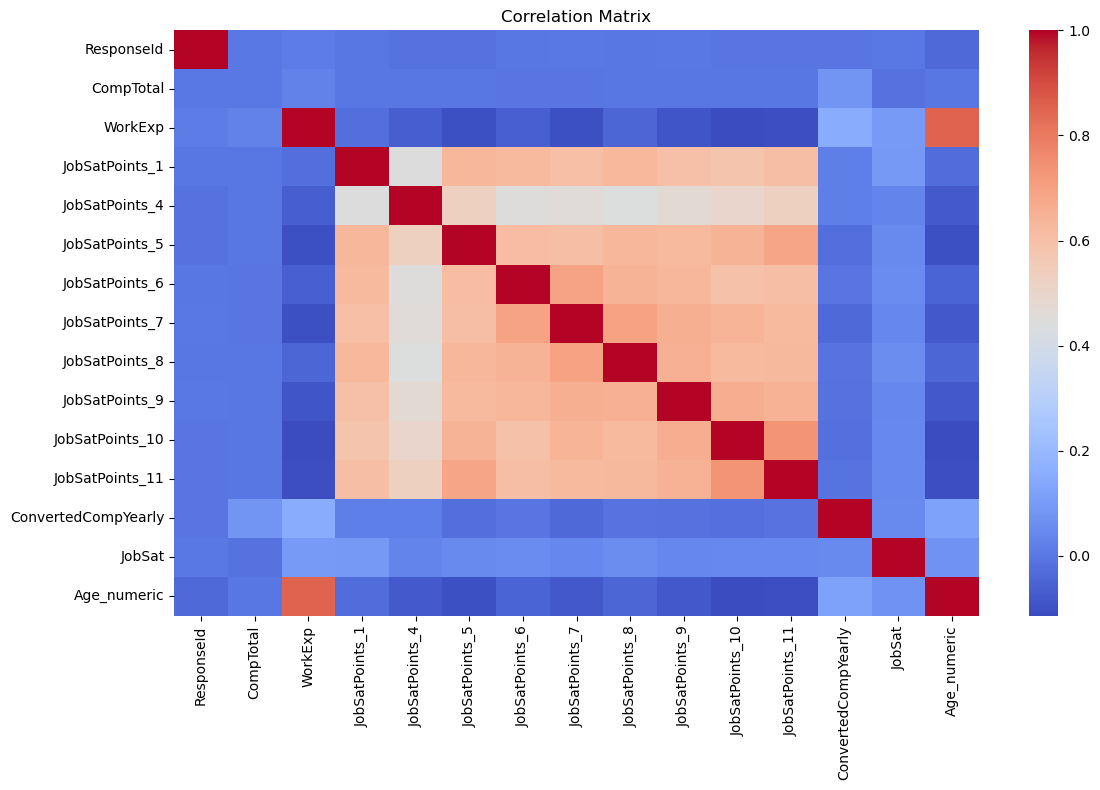

In [19]:
# Visualize correlation matrix

plt.figure(figsize=(12,8))

sns.heatmap(
    correlation_matrix,
    cmap='coolwarm',
    annot=False
)

plt.title('Correlation Matrix')

plt.tight_layout()
plt.show()

<h3> Summary </h3>

In this lab, you developed essential skills in **Exploratory Data Analysis (EDA)** with a focus on outlier detection and removal. Specifically, you:

- Loaded and explored the dataset to understand its structure.

- Analyzed the distribution of respondents across industries.

- Identified and removed high compensation outliers using statistical thresholds and the Interquartile Range (IQR) method.

- Performed correlation analysis, including transforming the `Age` column into numeric values for better analysis.